In [546]:
from __future__ import annotations

import math
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

In [ ]:
@dataclass
class Config:
    # Environment
    P0: float = 100.0
    mu: float = 0.0          # annualised drift (will be rescaled per dt)
    sigma: float = 0.2      # annualised volatility
    dt: float = 1.0 / (252 * 6.5 * 60 / 15)  # 15-min bars by default
    n_investors: int = 20
    investor_shape: float = 2.0  # Gamma shape for order size
    investor_scale: float = 1.0   # Gamma scale for order size
    base_spread_bp: float = 2.0   # best-level reference-spread in basis-points
    lob_slope_bp: float = 0.2     # spread widening per sqrt{v} in bp

    # PPO
    rollout: int = 100
    horizon: int = 2048
    n_epochs: int = 50
    minibatch_size: int = 128
    gamma: float = 0.999
    gae_lambda: float = 0.95
    clip_eps: float = 0.2
    lr: float = 1e-7
    vf_coef: float = 0.5
    ent_coef: float = 3e-3
    max_grad_norm: float = 0.5
    total_steps: int = rollout * horizon
    seed: int = 42
    device: str = 'cpu'
    eval_every_updates: int = 4096   # run evaluation after this many PPO updates
    eval_days: int = 20            # simulate 5 trading days each eval
    hedge_gamma = 2.0
    alpha = 0.01


CFG = Config()
random.seed(CFG.seed)
np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)


# Environment
class DealerMarketEnv:
    """Single-maker dealer-market simulator."""

    def __init__(self):
        self.P0 = CFG.P0
        self.mu_dt = CFG.mu * CFG.dt
        self.sig_dt = CFG.sigma * math.sqrt(CFG.dt)
        self.t = 0
        self.reset()

    def _step_mid_price(self):
        z = np.random.randn()
        self.P *= math.exp((self.mu_dt - 0.5 * CFG.sigma ** 2 * CFG.dt) + self.sig_dt * z)

    def _reference_spread(self, v: float) -> float:
        base = CFG.base_spread_bp * 1e-4 * self.P  # convert bp → fraction of price
        widen = CFG.lob_slope_bp * 1e-4 * self.P * math.sqrt(max(v, 1e-8))
        return base + widen

    def reset(self):
        self.P = self.P0
        self.inventory = 0.0
        self.last_spread_pnl = 0.0
        self.last_inv_pnl = 0.0
        self.last_hedge_cost = 0.0
        return self._get_obs()

    def _get_obs(self):
        return np.array([
            self.inventory,
            self.P,
            self.last_spread_pnl,
            self.last_inv_pnl,
            self.last_hedge_cost
        ], dtype=np.float32)

    def step(self, action: np.ndarray):
        # 1. Parse & bound actions
        eps_b = float(np.clip(action[0], -1.0, 1.0))
        eps_s = float(np.clip(action[1], -1.0, 1.0))
        hedge_frac = float(np.clip(action[2], 0.0, 1.0))

        # 2. Generate investor flow (all flow hits our maker)
        trades = []  # (size, dir)
        for _ in range(CFG.n_investors):
            size = np.random.gamma(CFG.investor_shape, CFG.investor_scale)
            direction = 1 if np.random.rand() < 0.5 else -1  # +1 buy, -1 sell from maker perspective
            trades.append((size, direction))

        # 3. Compute spread PnL
        spread_pnl = 0.0
        for size, direction in trades:
            ref_spread = self._reference_spread(size)
            if direction == 1:  # maker buys (sets bid)
                spread = ref_spread * (1 + eps_b)
                spread_pnl += size * spread
            else:
                spread = ref_spread * (1 + eps_s)
                spread_pnl += size * spread
            self.inventory += direction * size

        # 4. Inventory PnL due to mid-price move
        old_P = self.P
        self._step_mid_price()
        inv_pnl = (self.P - old_P) * self.inventory

        # 5. Hedging
        hedge_size = -hedge_frac * self.inventory
        if abs(hedge_size) > 1e-6:
            spread_cost = self._reference_spread(abs(hedge_size))
            if hedge_size > 0:  # we buy back inventory (sell side previously dominant)
                hedge_price = self.P + spread_cost
            else:  # we sell inventory
                hedge_price = self.P - spread_cost
            hedge_cost = hedge_size * (hedge_price - self.P)  
            self.inventory += hedge_size
        else:
            hedge_cost = 0.0

        # 6. Reward & bookkeeping
        reward = spread_pnl + inv_pnl - hedge_cost  
        self.last_spread_pnl, self.last_inv_pnl, self.last_hedge_cost = spread_pnl, inv_pnl, -hedge_cost
        self.t += 1
        done = False  # we don't terminate the trajectory in the environment
        info = {}     # not sure what to put in here. Leave it blank
        return self._get_obs(), reward, done, info

    def render(self):
        print(f"t={self.t:5d} P={self.P:8.2f} Inv={self.inventory:7.2f}  ΔPnL={self.last_spread_pnl + self.last_inv_pnl + self.last_hedge_cost:7.2f}")



In [549]:
# --------------------------
# Random Market Maker agent
# --------------------------
class RandomMarketMaker:
    """
    Chooses:
        ε_b, ε_s   ~ U(-1, 1)
        hedge_frac ~ 0   (never hedges; you can change to U(0,1) if desired)
    """

    def __init__(self, env, eps_b_max = 1, eps_s_max = 1, hedge_frac_max = 0.5):
        self.env = env
        self.eps_b_max = eps_b_max
        self.eps_s_max = eps_s_max
        self.hedge_frac_max = hedge_frac_max

    def act(self) -> np.ndarray:
        eps_b = np.random.uniform(-self.eps_b_max, self.eps_b_max)
        eps_s = np.random.uniform(-self.eps_s_max, self.eps_s_max)
        hedge_frac = np.random.uniform(0, self.hedge_frac_max)
        return np.array([eps_b, eps_s, hedge_frac], dtype=np.float32)
    
    def evaluate_random(self, eval_fold, days):
        pnl_return_list = []
        for fold in range(eval_fold):
            steps = int(days * 60 * 6.5 // 15)
            obs = self.env.reset()
            pnl_history = []
            inventory_history = []
            for _ in range(steps):
                action = self.act()
                obs, reward, _, _ = self.env.step(action)
                pnl_history.append(reward)
                inventory_history.append(self.env.inventory)
            pnl_return_list.append(np.sum(np.array(pnl_history)))
        return np.array(pnl_return_list)


In [190]:
env_random = DealerMarketEnv()
rand_agent = RandomMarketMaker(env = env_random)
pnl_list_eps_one = rand_agent.evaluate_random(eval_fold = 1000, days = 26)

In [191]:
print(np.mean(pnl_list_eps_one))
print(np.std(pnl_list_eps_one))

574.4841649752562
111.64042663795429


In [188]:
env_random = DealerMarketEnv()
rand_agent = RandomMarketMaker(env = env_random, eps_b_max=0.5, eps_s_max=0.5)
pnl_list_eps_half = rand_agent.evaluate_random(eval_fold = 1000, days = 26)

In [189]:
print(np.mean(pnl_list_eps_half))
print(np.std(pnl_list_eps_half))

577.1805198448632
113.95490686717825


In [186]:
env_random = DealerMarketEnv()
rand_agent = RandomMarketMaker(env = env_random, eps_b_max=1, eps_s_max=1, hedge_frac_max=0)
pnl_list_no_hedge = rand_agent.evaluate_random(eval_fold = 1000, days = 26)

In [187]:
print(np.mean(pnl_list_no_hedge))
print(np.std(pnl_list_no_hedge))

639.1367379797108
1243.2725480661861


In [551]:

# ================================
# 3. Neural Networks
# ================================
class PolicyValueNet(nn.Module):
    def __init__(self, obs_dim: int, act_dim: int):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh()
        )
        self.mu_head = nn.Linear(256, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))
        self.v_head = nn.Linear(256, 1)

    def forward(self, x):
        h = self.shared(x)
        mu_raw = self.mu_head(h)            # unconstrained
        # print(mu_raw.shape)
        eps_mu = torch.tanh(mu_raw[..., :2])  # now in [−1,1]
        x_mu   = torch.sigmoid(mu_raw[..., 2:])  # now in [0,1]
        mu = torch.cat([eps_mu, x_mu], dim=-1)
        return mu, self.v_head(h).squeeze(-1)

    def get_dist_value(self, x):
        mu, v = self.forward(x)
        std = self.log_std.exp().expand_as(mu)
        dist = torch.distributions.Normal(mu, std)
        return dist, v



In [ ]:

# ================================
# 4. PPO Agent
# ================================
class PPOBuffer:
    """Rollout buffer with GAE-λ."""

    def __init__(self, obs_dim, act_dim, size):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf = np.zeros((size, act_dim), dtype=np.float32)
        self.adv_buf = np.zeros(size, dtype=np.float32)
        self.rew_buf = np.zeros(size, dtype=np.float32)
        self.ret_buf = np.zeros(size, dtype=np.float32)
        self.logp_buf = np.zeros(size, dtype=np.float32)
        self.val_buf = np.zeros(size, dtype=np.float32)
        self.eval_step_buf = []
        self.eval_mean_buf = []
        self.eval_inventory_buf = []
        self.eval_std_buf = []
        self.ptr, self.path_start_idx, self.max_size = 0, 0, size

    def store(self, obs, act, rew, val, logp):
        assert self.ptr < self.max_size
        self.obs_buf[self.ptr] = obs
        self.act_buf[self.ptr] = act
        self.rew_buf[self.ptr] = rew
        self.val_buf[self.ptr] = val
        self.logp_buf[self.ptr] = logp
        self.ptr += 1

    def finish_path(self, last_val=0):
        path_slice = slice(self.path_start_idx, self.ptr)
        rews = np.append(self.rew_buf[path_slice], last_val)
        vals = np.append(self.val_buf[path_slice], last_val)
        # GAE-λ
        deltas = rews[:-1] + CFG.gamma * vals[1:] - vals[:-1]
        self.adv_buf[path_slice] = discount_cumsum(deltas, CFG.gamma * CFG.gae_lambda)
        # returns
        self.ret_buf[path_slice] = discount_cumsum(rews, CFG.gamma)[:-1]
        self.path_start_idx = self.ptr

    def get(self):
        self.ptr, self.path_start_idx = 0, 0
        adv_mean, adv_std = self.adv_buf.mean(), self.adv_buf.std() + 1e-8
        self.adv_buf = (self.adv_buf - adv_mean) / adv_std
        return [self.obs_buf, self.act_buf, self.adv_buf, self.ret_buf, self.logp_buf]


def discount_cumsum(x, discount):
    return np.array([sum(discount ** i * x[t + i] for i in range(len(x) - t)) for t in range(len(x))], dtype=np.float32)


class PPOAgent:
    def __init__(self, env: DealerMarketEnv, adapt_hedge = False, eval_fold = 30, eval_days = 30):
        self.env = env
        obs_dim = env.reset().shape[0]
        act_dim = 3
        self.net = PolicyValueNet(obs_dim, act_dim).to(CFG.device)
        self.opt = optim.Adam(self.net.parameters(), lr=CFG.lr)
        self.buf = PPOBuffer(obs_dim, act_dim, CFG.horizon)
        self.eval_fold = eval_fold
        self.eval_days = eval_days
        self.adapt_hedge = adapt_hedge

    def select_action(self, obs: np.ndarray):
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=CFG.device)
        dist, v = self.net.get_dist_value(obs_t)
        act = dist.sample()
        logp = dist.log_prob(act).sum(axis=-1)
        return act.cpu().numpy(), v.item(), logp.item()
    
        # ---------- Deterministic evaluation ----------
    @torch.no_grad()
    def evaluate(self, eval_fold, days):
        """Run *deterministic* policy for `days` and print PnL/inventory stats."""
        pnl_eval_list = []
        pnl_per_step_list = []
        for fold in range(eval_fold):
            self.net.eval()
            steps_per_day = int(6.5 * 60 / 15)  # 26
            T = steps_per_day * days
            env_eval = DealerMarketEnv()
            obs = env_eval.reset()
            pnl = 0.0
            for _ in range(T):
                mu, _ = self.net.forward(torch.as_tensor(obs, dtype=torch.float32, device=CFG.device))
                act = mu.cpu().numpy()
                obs, r, _, _ = env_eval.step(act)
                pnl += r
                pnl_per_step_list.append(r)
            pnl_eval_list.append(pnl)
            self.net.train()
        pnl_eval_list = np.array(pnl_eval_list)
        return np.mean(pnl_eval_list), np.std(pnl_eval_list)

    def train(self):
        obs, ep_ret, ep_len = self.env.reset(), 0, 0
        total_steps = 0
        ep_returns = []

        # Precompute E[v_eps^2] for the Gamma investor flow:
        E_v2 = CFG.investor_shape * CFG.investor_scale**2 \
             + (CFG.investor_shape * CFG.investor_scale)**2

        while total_steps < CFG.total_steps:
            for t in range(CFG.horizon):
                act, val, logp = self.select_action(obs)
                next_obs, rew, done, _ = self.env.step(act)

                if self.adapt_hedge == True: # Compute cost_{hedge}
                    inv_after = self.env.inventory

                    risk_term = math.sqrt(inv_after**2 + E_v2) * self.env.sig_dt
                    risk_penalty = CFG.alpha * (self.env.last_inv_pnl**2)
                    # print(self.env.last_inv_pnl)
                    
                    rew = rew - risk_penalty

                self.buf.store(obs, act, rew, val, logp)
                obs = next_obs
                ep_ret += rew
                ep_len += 1
                total_steps += 1
                terminal = done or (t == CFG.horizon - 1)
                if terminal:
                    last_val = 0 if done else self.net.get_dist_value(torch.as_tensor(obs, dtype=torch.float32, device=CFG.device))[1].item()
                    self.buf.finish_path(last_val)
                    ep_returns.append(ep_ret)
                    obs, ep_ret, ep_len = self.env.reset(), 0, 0

            
            if total_steps % CFG.eval_every_updates == 0 or total_steps == CFG.total_steps - 1:
                mean, std = self.evaluate(eval_fold=self.eval_fold, days=self.eval_days)
                print(f"30‑day cumulative PnL: Mean {mean:.2f}. Std {std:.2f}")
                self.buf.eval_step_buf.append(total_steps)
                self.buf.eval_mean_buf.append(mean)
                self.buf.eval_std_buf.append(std)

                print(f"{total_steps:8d} steps  avg return:{np.mean(ep_returns[-10:]):8.2f}")

            # PPO update
            self._update()

    def _update(self):
        obs_buf, act_buf, adv_buf, ret_buf, logp_buf = [torch.as_tensor(x, device=CFG.device) for x in self.buf.get()]
        for _ in range(CFG.n_epochs):
            idx = np.random.permutation(CFG.horizon)
            for start in range(0, CFG.horizon, CFG.minibatch_size):
                mb_idx = idx[start:start + CFG.minibatch_size]
                dist, value = self.net.get_dist_value(obs_buf[mb_idx])
                new_logp = dist.log_prob(act_buf[mb_idx]).sum(axis=-1)
                ratio = (new_logp - logp_buf[mb_idx]).exp()
                surr1 = ratio * adv_buf[mb_idx]
                surr2 = torch.clamp(ratio, 1 - CFG.clip_eps, 1 + CFG.clip_eps) * adv_buf[mb_idx]
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss = ((ret_buf[mb_idx] - value) ** 2).mean()
                entropy = dist.entropy().sum(axis=-1).mean()
                loss = policy_loss + CFG.vf_coef * value_loss - CFG.ent_coef * entropy
                self.opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), CFG.max_grad_norm)
                self.opt.step()



In [269]:
env = DealerMarketEnv()
agent_nonlinear = PPOAgent(env, adapt_hedge=True, eval_days=20)
agent_nonlinear.train()

30‑day cumulative PnL: Mean 777.86. Std 680.53
    4096 steps  avg return: -612.06
30‑day cumulative PnL: Mean 639.68. Std 100.04
    8192 steps  avg return: -460.44
30‑day cumulative PnL: Mean 644.05. Std 70.93
   12288 steps  avg return: -274.85
30‑day cumulative PnL: Mean 646.34. Std 75.97
   16384 steps  avg return:  -37.07
30‑day cumulative PnL: Mean 709.00. Std 70.98
   20480 steps  avg return:  158.52
30‑day cumulative PnL: Mean 748.00. Std 61.55
   24576 steps  avg return: -619.68
30‑day cumulative PnL: Mean 738.99. Std 60.67
   28672 steps  avg return: -697.63
30‑day cumulative PnL: Mean 709.65. Std 71.19
   32768 steps  avg return:  -91.88
30‑day cumulative PnL: Mean 690.48. Std 77.83
   36864 steps  avg return:   58.56
30‑day cumulative PnL: Mean 731.67. Std 70.83
   40960 steps  avg return:   46.02
30‑day cumulative PnL: Mean 665.74. Std 89.75
   45056 steps  avg return:   62.60
30‑day cumulative PnL: Mean 684.26. Std 84.41
   49152 steps  avg return:   20.07
30‑day cumulat

In [233]:
env = DealerMarketEnv()
agent = PPOAgent(env, eval_days=20)
agent.train()

# Save checkpoint
Path("checkpoints").mkdir(exist_ok=True)
torch.save(agent.net.state_dict(), f"checkpoints/ppo_single_maker.pt")


30‑day cumulative PnL: Mean 339.32. Std 637.34
    4096 steps  avg return:  650.95
30‑day cumulative PnL: Mean 288.85. Std 606.84
    8192 steps  avg return:  629.64
30‑day cumulative PnL: Mean 428.15. Std 704.14
   12288 steps  avg return:  656.72
30‑day cumulative PnL: Mean 225.69. Std 447.64
   16384 steps  avg return:  749.00
30‑day cumulative PnL: Mean 661.00. Std 553.59
   20480 steps  avg return:  807.54
30‑day cumulative PnL: Mean 690.43. Std 762.87
   24576 steps  avg return:  883.14
30‑day cumulative PnL: Mean 515.16. Std 795.00
   28672 steps  avg return:  986.75
30‑day cumulative PnL: Mean 495.82. Std 546.95
   32768 steps  avg return: 1051.17
30‑day cumulative PnL: Mean 620.72. Std 651.07
   36864 steps  avg return: 1127.61
30‑day cumulative PnL: Mean 853.00. Std 678.69
   40960 steps  avg return: 1185.83
30‑day cumulative PnL: Mean 884.49. Std 654.01
   45056 steps  avg return: 1275.75
30‑day cumulative PnL: Mean 697.78. Std 735.85
   49152 steps  avg return: 1276.39
30‑d

In [231]:
# alpha = 0.4 case
env = DealerMarketEnv()
agent_hedge = PPOAgent(env, adapt_hedge = True, eval_days=20)
agent_hedge.train()

Path("checkpoints").mkdir(exist_ok=True)
torch.save(agent.net.state_dict(), f"checkpoints/ppo_single_maker_hedge.pt")

30‑day cumulative PnL: Mean 244.03. Std 256.24
    4096 steps  avg return:  199.65
30‑day cumulative PnL: Mean 290.05. Std 97.22
    8192 steps  avg return:  174.63
30‑day cumulative PnL: Mean 296.57. Std 94.95
   12288 steps  avg return:  192.70
30‑day cumulative PnL: Mean 347.66. Std 143.90
   16384 steps  avg return:  219.75
30‑day cumulative PnL: Mean 349.23. Std 108.56
   20480 steps  avg return:  281.40
30‑day cumulative PnL: Mean 376.75. Std 135.13
   24576 steps  avg return:  347.17
30‑day cumulative PnL: Mean 380.09. Std 122.78
   28672 steps  avg return:  412.29
30‑day cumulative PnL: Mean 439.89. Std 105.92
   32768 steps  avg return:  462.02
30‑day cumulative PnL: Mean 449.91. Std 57.28
   36864 steps  avg return:  552.95
30‑day cumulative PnL: Mean 555.36. Std 118.40
   40960 steps  avg return:  535.75
30‑day cumulative PnL: Mean 548.14. Std 88.45
   45056 steps  avg return:  576.57
30‑day cumulative PnL: Mean 617.40. Std 90.94
   49152 steps  avg return:  627.27
30‑day cu

In [311]:
agent_hedge.buf.act_buf[-9]

array([1.7856934, 1.6677214, 1.3647134], dtype=float32)

In [338]:
# alpha = 0.01 case

env = DealerMarketEnv()
agent_hedge_weak = PPOAgent(env, adapt_hedge = True, eval_days=20)
agent_hedge_weak.train()

30‑day cumulative PnL: Mean 467.24. Std 86.46
    4096 steps  avg return:  -32.35
30‑day cumulative PnL: Mean 596.53. Std 61.99
    8192 steps  avg return:   -4.57
30‑day cumulative PnL: Mean 633.29. Std 61.59
   12288 steps  avg return:   38.80
30‑day cumulative PnL: Mean 563.52. Std 86.13
   16384 steps  avg return:   33.04
30‑day cumulative PnL: Mean 636.74. Std 68.96
   20480 steps  avg return:   51.35
30‑day cumulative PnL: Mean 643.90. Std 62.73
   24576 steps  avg return:   54.54
30‑day cumulative PnL: Mean 643.61. Std 76.01
   28672 steps  avg return:   92.10
30‑day cumulative PnL: Mean 695.20. Std 71.73
   32768 steps  avg return:  163.75
30‑day cumulative PnL: Mean 667.85. Std 59.20
   36864 steps  avg return:  260.58
30‑day cumulative PnL: Mean 692.69. Std 58.58
   40960 steps  avg return:  274.65
30‑day cumulative PnL: Mean 718.28. Std 58.16
   45056 steps  avg return:  291.37
30‑day cumulative PnL: Mean 695.89. Std 70.51
   49152 steps  avg return:  347.92
30‑day cumulativ

KeyboardInterrupt: 

In [327]:
agent_hedge_weak.buf.act_buf[-5:]

array([[ 0.08203375,  1.6610936 ,  1.4231352 ],
       [-0.29307944, -0.32360274,  1.6871934 ],
       [ 0.46871817,  2.064004  ,  1.1432407 ],
       [ 3.3433712 ,  0.9374855 ,  1.6383708 ],
       [ 0.11665195,  1.4797449 ,  0.1803984 ]], dtype=float32)

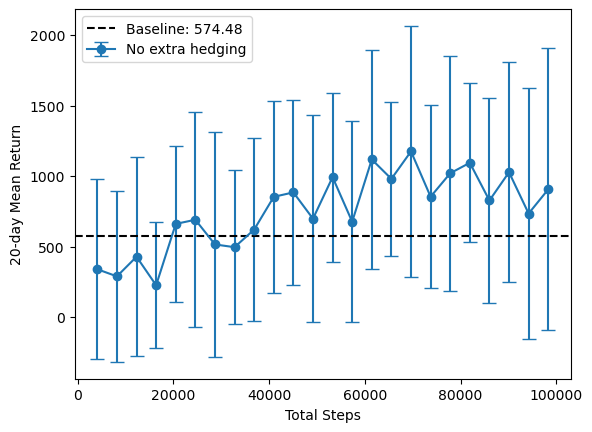

In [297]:
step_logs = agent.buf.eval_step_buf
mean_logs = agent.buf.eval_mean_buf
std_logs = agent.buf.eval_std_buf
plt.errorbar(step_logs, mean_logs, yerr=std_logs, fmt='o-', capsize=5, label='No extra hedging')

# mean_logs = agent_nonlinear.buf.eval_mean_buf
# std_logs = agent_nonlinear.buf.eval_std_buf
# plt.errorbar(step_logs, mean_logs, yerr=std_logs, fmt='o-', capsize=5, label = 'Nonlinear hedging')

# mean_logs = agent_hedge.buf.eval_mean_buf
# std_logs = agent_hedge.buf.eval_std_buf
# plt.errorbar(step_logs, mean_logs, yerr=std_logs, fmt='o-', capsize=5, label = 'Linear hedging')

# mean_logs = agent_hedge_weak.buf.eval_mean_buf
# std_logs = agent_hedge_weak.buf.eval_std_buf
# plt.errorbar(step_logs, mean_logs, yerr=std_logs, fmt='o-', capsize=5, label = 'alpha = 0.01')

plt.axhline(np.mean(pnl_list_eps_one), color='black', linestyle='--', label=f'Baseline: {np.mean(pnl_list_eps_one):.2f}')

plt.xlabel('Total Steps')
plt.ylabel('20-day Mean Return')
plt.legend()
plt.show()


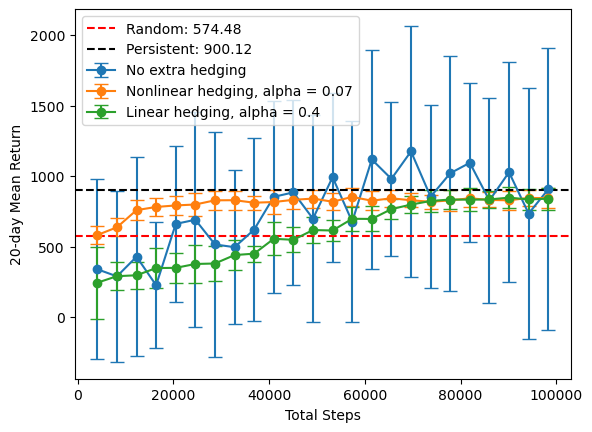

In [326]:
step_logs = agent.buf.eval_step_buf
mean_logs = agent.buf.eval_mean_buf
std_logs = agent.buf.eval_std_buf
plt.errorbar(step_logs, mean_logs, yerr=std_logs, fmt='o-', capsize=5, label='No extra hedging')

mean_logs = agent_hedge_weak.buf.eval_mean_buf
std_logs = agent_hedge_weak.buf.eval_std_buf
plt.errorbar(step_logs, mean_logs, yerr=std_logs, fmt='o-', capsize=5, label = 'Nonlinear hedging, alpha = 0.07')

mean_logs = agent_hedge.buf.eval_mean_buf
std_logs = agent_hedge.buf.eval_std_buf
plt.errorbar(step_logs, mean_logs, yerr=std_logs, fmt='o-', capsize=5, label = 'Linear hedging, alpha = 0.4')

# mean_logs = agent_hedge_weak.buf.eval_mean_buf
# std_logs = agent_hedge_weak.buf.eval_std_buf
# plt.errorbar(step_logs, mean_logs, yerr=std_logs, fmt='o-', capsize=5, label = 'alpha = 0.01')

plt.axhline(np.mean(pnl_list_eps_one), color='red', linestyle='--', label=f'Random: {np.mean(pnl_list_eps_one):.2f}')
plt.axhline(np.mean(pnl_list_persistent), color='black', linestyle='--', label=f'Persistent: {np.mean(pnl_list_persistent):.2f}')

plt.xlabel('Total Steps')
plt.ylabel('20-day Mean Return')
plt.legend()
plt.show()


In [252]:
# alpha = 0.01, clip_eps = 0.5
CFG.clip_eps = 0.1
env = DealerMarketEnv()
agent_clip = PPOAgent(env, adapt_hedge = True, eval_days=20)
agent_clip.train()

30‑day cumulative PnL: Mean 357.10. Std 89.96
    4096 steps  avg return:  523.89
30‑day cumulative PnL: Mean 425.55. Std 72.09
    8192 steps  avg return:  572.03
30‑day cumulative PnL: Mean 442.62. Std 89.72
   12288 steps  avg return:  617.65
30‑day cumulative PnL: Mean 463.37. Std 160.37
   16384 steps  avg return:  722.20
30‑day cumulative PnL: Mean 580.74. Std 207.00
   20480 steps  avg return:  753.00
30‑day cumulative PnL: Mean 617.31. Std 122.66
   24576 steps  avg return:  774.20
30‑day cumulative PnL: Mean 653.46. Std 142.52
   28672 steps  avg return:  913.60
30‑day cumulative PnL: Mean 602.82. Std 275.33
   32768 steps  avg return:  960.81
30‑day cumulative PnL: Mean 827.68. Std 330.83
   36864 steps  avg return:  938.78
30‑day cumulative PnL: Mean 731.12. Std 402.92
   40960 steps  avg return:  910.88
30‑day cumulative PnL: Mean 776.17. Std 418.22
   45056 steps  avg return: 1019.56
30‑day cumulative PnL: Mean 828.35. Std 403.26
   49152 steps  avg return: 1100.37
30‑day 

In [261]:
# clip = 0.5 case

CFG.clip_eps = 0.19
env = DealerMarketEnv()
agent_clip_2 = PPOAgent(env, adapt_hedge = True, eval_days=20)
agent_clip_2.train()

30‑day cumulative PnL: Mean 495.78. Std 580.81
    4096 steps  avg return:  722.09
30‑day cumulative PnL: Mean 457.66. Std 629.60
    8192 steps  avg return:  605.27
30‑day cumulative PnL: Mean 757.90. Std 723.07
   12288 steps  avg return:  633.81
30‑day cumulative PnL: Mean 687.81. Std 708.39
   16384 steps  avg return:  729.45
30‑day cumulative PnL: Mean 714.20. Std 141.53
   20480 steps  avg return:  879.34
30‑day cumulative PnL: Mean 822.43. Std 481.00
   24576 steps  avg return:  952.27
30‑day cumulative PnL: Mean 747.72. Std 298.37
   28672 steps  avg return: 1027.94
30‑day cumulative PnL: Mean 805.75. Std 155.03
   32768 steps  avg return: 1107.68
30‑day cumulative PnL: Mean 721.59. Std 883.90
   36864 steps  avg return: 1149.70
30‑day cumulative PnL: Mean 1017.97. Std 273.25
   40960 steps  avg return: 1115.67
30‑day cumulative PnL: Mean 860.28. Std 146.45
   45056 steps  avg return: 1117.52
30‑day cumulative PnL: Mean 628.51. Std 850.92
   49152 steps  avg return: 1110.17
30‑

In [418]:
import numpy as np

class PersistentAgent:
    """
    Baseline agent: fixed pricing offsets (eps_b, eps_s) and fixed hedge fraction x.
    """
    def __init__(self, env, eps_b: float, eps_s: float, hedge_x: float):
        self.env = env
        # Clip to valid ranges once
        self.eps_b  = float(np.clip(eps_b, -1.0, 1.0))
        self.eps_s  = float(np.clip(eps_s, -1.0, 1.0))
        self.hedge_x = float(np.clip(hedge_x, 0.0, 1.0))

    def act(self):
        return np.array([self.eps_b, self.eps_s, self.hedge_x], dtype=np.float32)

    def run(self, num_steps: int):
        obs = self.env.reset()
        total_reward = 0.0
        for t in range(num_steps):
            action = self.act()
            obs, reward, done, info = self.env.step(action)
            total_reward += reward
            if done:  # though done is always False in this env
                obs = self.env.reset()
        return total_reward
    
    




In [300]:
# Example usage:

pnl_list_persistent = []

for _ in range(100):
    env = DealerMarketEnv()
    agent_persistent = PersistentAgent(env, eps_b=0.5, eps_s=0.5, hedge_x=0.3)
    cum_pnl = agent_persistent.run( int(20*6.5*60 //15) )
    pnl_list_persistent.append(cum_pnl)

pnl_list_persistent = np.array(pnl_list_persistent)
print(np.mean(pnl_list_persistent), np.std(pnl_list_persistent))

900.1157631860947 78.52191405459295


In [735]:
class DealerMarketEnv2:
    """
    Dealer-market with **two** makers:
      mm_id = 0 : PPO agent   (we’ll give action via .step())
      mm_id = 1 : RandomMM    (internal; env samples action each step)
    Investors trade with the maker offering *better* spread;
    ties go 50-50.
    """

    def __init__(self):
        self.P0 = CFG.P0
        self.mu_dt = CFG.mu * CFG.dt
        self.sig_dt = CFG.sigma * math.sqrt(CFG.dt)
        self.rnd_mm = RandomMarketMaker(self, 1, 1, 0.3)
        # self.rnd_mm = PersistentAgent(self, 0.5, 0.5, 0)
        self.t = 0
        self.reset()

    # ------------- helpers (same as before) -----------------
    def _step_mid_price(self):
        z = np.random.randn()
        self.P *= math.exp((self.mu_dt - 0.5 * CFG.sigma**2 * CFG.dt) + self.sig_dt * z)

    def _reference_spread(self, v):
        base  = CFG.base_spread_bp * 1e-4 * self.P
        widen = CFG.lob_slope_bp  * 1e-4 * self.P * math.sqrt(max(v, 1e-8))
        return base + widen
    # --------------------------------------------------------

    def reset(self):
        self.P = self.P0
        self.inv   = [0.0, 0.0]      # inventory for each MM
        self.last_r = [0.0, 0.0]     # last-step pnl for each MM
        self.last_inv_pnl = [0.0, 0.0]
        self.last_hedge_cost = [0.0, 0.0]
        return self._get_obs(mm=0)   # we only give PPO its own obs

    def _get_obs(self, mm):
        """Obs for maker mm (here only mm=0 is exposed)."""
        return np.array([
            self.inv[mm],      # its inventory
            self.P,
            self.last_r[mm],   # its last-step PnL
            self.last_inv_pnl[mm], 
            self.last_hedge_cost[mm]
        ], dtype=np.float32)

    # ------------ MAIN STEP ---------------------------------
    def step(self, rl_action):
        """
        rl_action : np.array([ε_b, ε_s, x]) for maker 0.
        Maker 1’s action is drawn internally from RandomMM.
        Investors route to the maker with smaller (ask+bid)/2 spread.
        """
        acts = [rl_action, self.rnd_mm.act()]
        spreads = []  # [(eps_b,eps_s), ...]
        for a in acts:
            eps_b = float(np.clip(a[0], -1.0, 1.0))
            eps_s = float(np.clip(a[1], -1.0, 1.0))
            hedge = float(np.clip(a[2],  0.0, 1.0))
            spreads.append((eps_b, eps_s))

        # 1. generate investor flow
        trades = []
        for _ in range(CFG.n_investors):
            size = np.random.gamma(CFG.investor_shape, CFG.investor_scale)
            buy  = (np.random.rand() < 0.5)   # True = investor buys (MM sells)
            trades.append((size, +1 if buy else -1))

        # 2. allocate each trade to the maker with better price
        pnl = [0.0, 0.0]
        for size, dir_ in trades:
            ref_spread = self._reference_spread(size)
            # effective price difference each maker offers
            price_diff = []
            for eps_b, eps_s in spreads:
                if dir_ == +1:                    # investor BUYs, maker SELLS
                    spread = ref_spread * (1 + eps_s)
                    price  = self.P + spread      # ask
                else:                             # investor SELLs, maker BUYs
                    spread = ref_spread * (1 + eps_b)
                    price  = self.P - spread      # bid
                price_diff.append(price)

            # choose maker with better price (lower ask or higher bid)
            best_mm = 0 if (
                (dir_==+1 and price_diff[0] <= price_diff[1]) or
                (dir_==-1 and price_diff[0] >= price_diff[1])
            ) else 1
            # ties split 50-50
            if price_diff[0] == price_diff[1] and np.random.rand() < 0.5:
                best_mm = 0

            # execute
            eps_b, eps_s = spreads[best_mm]
            spread_used  = ref_spread * (1 + (eps_s if dir_==+1 else eps_b))
            pnl[best_mm] += size * spread_used
            self.inv[best_mm] += dir_ * size

        # 3. mid-price move & inventory PnL
        old_P = self.P
        self._step_mid_price()
        for mm in (0,1):
            inv_pnl = (self.P - old_P) * self.inv[mm]
            pnl[mm] += inv_pnl
            self.last_inv_pnl[mm] = inv_pnl

        # 4. hedging for both makers
        for mm, a in enumerate(acts):
            hedge_frac = float(np.clip(a[2], 0.0, 1.0))
            hedge_size = -hedge_frac * self.inv[mm]
            if abs(hedge_size) > 1e-6:
                s = self._reference_spread(abs(hedge_size))
                hedge_price = self.P + s if hedge_size > 0 else self.P - s
                hedge_cost  = hedge_size * (hedge_price - self.P)
                pnl[mm]    -= hedge_cost
                self.inv[mm] += hedge_size
                self.last_hedge_cost[mm] = hedge_cost

        self.last_r = pnl
        self.t += 1

        done = False
        info = {"rnd_pnl": pnl[1]}   # random maker’s PnL
        return self._get_obs(mm=0), pnl[0], done, info


In [531]:
env = DealerMarketEnv2()
_, _, _, info = env.step(np.array([1,1,0.5]))

In [359]:
info['rnd_pnl']

0.11185133022003015

In [736]:
# ================================
# 4. PPO Agent
# ================================
class PPOBuffer:
    """Rollout buffer with GAE-λ."""

    def __init__(self, obs_dim, act_dim, size):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf = np.zeros((size, act_dim), dtype=np.float32)
        self.adv_buf = np.zeros(size, dtype=np.float32)
        self.rew_buf = np.zeros(size, dtype=np.float32)
        self.ret_buf = np.zeros(size, dtype=np.float32)
        self.logp_buf = np.zeros(size, dtype=np.float32)
        self.val_buf = np.zeros(size, dtype=np.float32)
        self.eval_step_buf = []
        self.eval_mean_buf = []
        self.eval_inventory_buf = []
        self.eval_std_buf = []
        self.eval_mean_buf_rd = []
        self.eval_std_buf_rd = []
        self.ptr, self.path_start_idx, self.max_size = 0, 0, size

    def store(self, obs, act, rew, val, logp):
        assert self.ptr < self.max_size
        self.obs_buf[self.ptr] = obs
        self.act_buf[self.ptr] = act
        self.rew_buf[self.ptr] = rew
        self.val_buf[self.ptr] = val
        self.logp_buf[self.ptr] = logp
        self.ptr += 1

    def finish_path(self, last_val=0):
        path_slice = slice(self.path_start_idx, self.ptr)
        rews = np.append(self.rew_buf[path_slice], last_val)
        vals = np.append(self.val_buf[path_slice], last_val)
        # GAE-λ
        deltas = rews[:-1] + CFG.gamma * vals[1:] - vals[:-1]
        self.adv_buf[path_slice] = discount_cumsum(deltas, CFG.gamma * CFG.gae_lambda)
        # returns
        self.ret_buf[path_slice] = discount_cumsum(rews, CFG.gamma)[:-1]
        self.path_start_idx = self.ptr

    def get(self):
        self.ptr, self.path_start_idx = 0, 0
        adv_mean, adv_std = self.adv_buf.mean(), self.adv_buf.std() + 1e-8
        self.adv_buf = (self.adv_buf - adv_mean) / adv_std
        return [self.obs_buf, self.act_buf, self.adv_buf, self.ret_buf, self.logp_buf]


def discount_cumsum(x, discount):
    return np.array([sum(discount ** i * x[t + i] for i in range(len(x) - t)) for t in range(len(x))], dtype=np.float32)


class PPOAgent:
    def __init__(self, env: DealerMarketEnv2, adapt_hedge = False, eval_fold = 30, eval_days = 30):
        self.env = env
        obs_dim = env.reset().shape[0]
        act_dim = 3
        self.net = PolicyValueNet(obs_dim, act_dim).to(CFG.device)
        self.opt = optim.Adam(self.net.parameters(), lr=CFG.lr)
        self.buf = PPOBuffer(obs_dim, act_dim, CFG.horizon)
        self.eval_fold = eval_fold
        self.eval_days = eval_days
        self.adapt_hedge = adapt_hedge

    def select_action(self, obs: np.ndarray):
        obs_t = torch.as_tensor(obs, dtype=torch.float32, device=CFG.device)
        dist, v = self.net.get_dist_value(obs_t)
        act = dist.sample()
        logp = dist.log_prob(act).sum(axis=-1)
        return act.cpu().numpy(), v.item(), logp.item()
    
        # ---------- Deterministic evaluation ----------
    @torch.no_grad()
    def evaluate(self, eval_fold, days):
        """Run *deterministic* policy for `days` and print PnL/inventory stats."""
        pnl_eval_list = []
        pnl_eval_list_rd = []
        for fold in range(eval_fold):
            self.net.eval()
            steps_per_day = int(6.5 * 60 / 15)  # 26
            T = steps_per_day * days
            env_eval = DealerMarketEnv2()
            obs = env_eval.reset()
            pnl = 0.0
            pnl_rd = 0.0
            for _ in range(T):
                mu, _ = self.net.forward(torch.as_tensor(obs, dtype=torch.float32, device=CFG.device))
                act = mu.cpu().numpy()
                obs, r, _, info = env_eval.step(act)
                pnl += r
                pnl_rd += info['rnd_pnl']
            pnl_eval_list.append(pnl)
            pnl_eval_list_rd.append(pnl_rd)
            self.net.train()
        pnl_eval_list = np.array(pnl_eval_list)
        pnl_eval_list_rd = np.array(pnl_eval_list_rd)
        return np.mean(pnl_eval_list), np.std(pnl_eval_list), np.mean(pnl_eval_list_rd), np.std(pnl_eval_list_rd)

    def train(self):
        obs, ep_ret, ep_len = self.env.reset(), 0, 0
        total_steps = 0
        ep_returns = []

        # Precompute E[v_eps^2] for the Gamma investor flow:
        # E_v2 = CFG.investor_shape * CFG.investor_scale**2 \
        #      + (CFG.investor_shape * CFG.investor_scale)**2

        while total_steps < CFG.total_steps:
            for t in range(CFG.horizon):
                act, val, logp = self.select_action(obs)
                next_obs, rew, done, _ = self.env.step(act)

                if self.adapt_hedge == True: # Compute cost_{hedge}
                    inv_after = self.env.inv[0]

                    # risk_term = math.sqrt(inv_after**2 + E_v2) * self.env.sig_dt
                    risk_penalty = 0.01 * (self.env.last_inv_pnl[0]**2)
                    # print(self.env.last_inv_pnl)
                    
                    rew = rew - risk_penalty

                self.buf.store(obs, act, rew, val, logp)
                obs = next_obs
                ep_ret += rew
                ep_len += 1
                total_steps += 1
                terminal = done or (t == CFG.horizon - 1)
                if terminal:
                    last_val = 0 if done else self.net.get_dist_value(torch.as_tensor(obs, dtype=torch.float32, device=CFG.device))[1].item()
                    self.buf.finish_path(last_val)
                    ep_returns.append(ep_ret)
                    obs, ep_ret, ep_len = self.env.reset(), 0, 0

            
            if total_steps % CFG.eval_every_updates == 0 or total_steps == CFG.total_steps - 1:
                mean, std, mean_rd, std_rd = self.evaluate(eval_fold=self.eval_fold, days=self.eval_days)
                print("20‑day cumulative PnL:", end = '\n')
                print(f"RL agent:  Mean {mean:.2f}. Std {std:.2f}", end = '\n')
                print(f"Persistent agent:  Mean {mean_rd:.2f}. Std {std_rd:.2f}", end = '\n')
                self.buf.eval_step_buf.append(total_steps)
                self.buf.eval_mean_buf.append(mean)
                self.buf.eval_std_buf.append(std)
                self.buf.eval_mean_buf_rd.append(mean_rd)
                self.buf.eval_std_buf_rd.append(std_rd)

                print(f"{total_steps:8d} steps: RL agent avg return:{np.mean(ep_returns[-10:]):8.2f}")

            # PPO update
            self._update()

    def _update(self):
        obs_buf, act_buf, adv_buf, ret_buf, logp_buf = [torch.as_tensor(x, device=CFG.device) for x in self.buf.get()]
        for _ in range(CFG.n_epochs):
            idx = np.random.permutation(CFG.horizon)
            for start in range(0, CFG.horizon, CFG.minibatch_size):
                mb_idx = idx[start:start + CFG.minibatch_size]
                dist, value = self.net.get_dist_value(obs_buf[mb_idx])
                new_logp = dist.log_prob(act_buf[mb_idx]).sum(axis=-1)
                ratio = (new_logp - logp_buf[mb_idx]).exp()
                surr1 = ratio * adv_buf[mb_idx]
                surr2 = torch.clamp(ratio, 1 - CFG.clip_eps, 1 + CFG.clip_eps) * adv_buf[mb_idx]
                policy_loss = -torch.min(surr1, surr2).mean()
                value_loss = ((ret_buf[mb_idx] - value) ** 2).mean()
                entropy = dist.entropy().sum(axis=-1).mean()
                loss = policy_loss + CFG.vf_coef * value_loss - CFG.ent_coef * entropy
                self.opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(self.net.parameters(), CFG.max_grad_norm)
                self.opt.step()

In [751]:
env = DealerMarketEnv2()                  # two-maker env
agent = PPOAgent(env, adapt_hedge=False, eval_days=20, eval_fold=5)
agent.train()


20‑day cumulative PnL:
RL agent:  Mean 86.73. Std 121.11
Persistent agent:  Mean 44.12. Std 240.14
    4096 steps: RL agent avg return: -222.80
20‑day cumulative PnL:
RL agent:  Mean 67.72. Std 115.51
Persistent agent:  Mean 174.67. Std 173.39
    8192 steps: RL agent avg return: -248.44
20‑day cumulative PnL:
RL agent:  Mean 130.97. Std 78.13
Persistent agent:  Mean -2.95. Std 109.37
   12288 steps: RL agent avg return: -152.25
20‑day cumulative PnL:
RL agent:  Mean 95.96. Std 106.47
Persistent agent:  Mean 176.54. Std 78.64
   16384 steps: RL agent avg return:  -88.17
20‑day cumulative PnL:
RL agent:  Mean 156.14. Std 72.14
Persistent agent:  Mean 28.34. Std 148.43
   20480 steps: RL agent avg return:  -83.95
20‑day cumulative PnL:
RL agent:  Mean 146.07. Std 37.00
Persistent agent:  Mean 129.51. Std 141.83
   24576 steps: RL agent avg return:  -64.70
20‑day cumulative PnL:
RL agent:  Mean 121.30. Std 51.86
Persistent agent:  Mean 36.02. Std 107.29
   28672 steps: RL agent avg return

In [746]:
agent.net.eval() 

eps_b_list = []
eps_s_list = []
pnl_list = []
pnl_per_list = []

obs = env.reset()
with torch.no_grad():
    for step in range(3000):
        mu, _ = agent.net.forward(
            torch.as_tensor(obs, dtype=torch.float32, device=CFG.device)
        )
        act = mu.cpu().numpy()           # deterministic (mean) action
        eps_b, eps_s = act[:2]           # first two components
        eps_b_list.append(eps_b)
        eps_s_list.append(eps_s)

        obs, reward, done, info = env.step(act)
        pnl_list.append(reward)
        pnl_per_list.append(info['rnd_pnl'])

print(np.sum(np.array(pnl_list)), np.sum(np.array(pnl_per_list)))

729.7957441486557 840.5582937792838


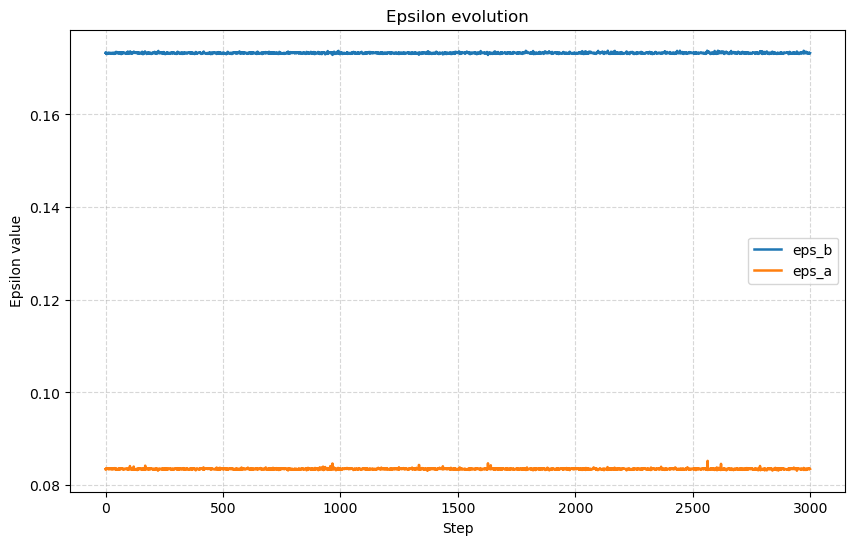

In [750]:
epsilons = np.column_stack([eps_b_list, eps_s_list])  # shape (T, 2)

T = epsilons.shape[0]
steps = np.arange(T)

eps_b = epsilons[:, 0]
eps_s = epsilons[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(steps, eps_b, label='eps_b', linewidth=1.8)
plt.plot(steps, eps_s, label='eps_a', linewidth=1.8)

plt.xlabel('Step')
plt.ylabel('Epsilon value')
plt.title('Epsilon evolution')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
# plt.tight_layout()
plt.show()

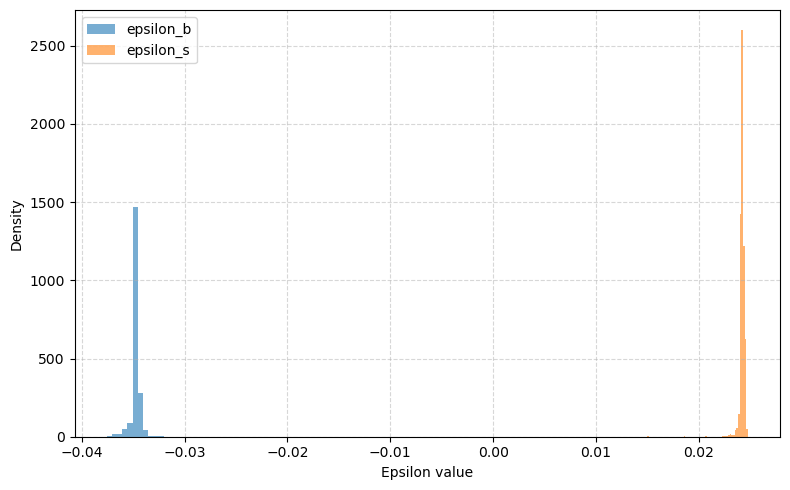

In [740]:
# epsilons = np.column_stack([eps_b_list, eps_s_list])  # shape (T, 2)

plt.figure(figsize=(8, 5))

plt.hist(epsilons[:, 0], bins=61, density=True, alpha=0.6, label='epsilon_b')
plt.hist(epsilons[:, 1], bins=61, density=True, alpha=0.6, label='epsilon_s')

plt.xlabel('Epsilon value')
plt.ylabel('Density')
# plt.title('Empirical density of ε_b and ε_s')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [728]:
print(np.mean(eps_b))
print(np.mean(eps_s))
print(np.std(eps_s))
print(np.std(eps_b))

0.24613397
0.31623033
1.5816772e-08
3.283782e-08


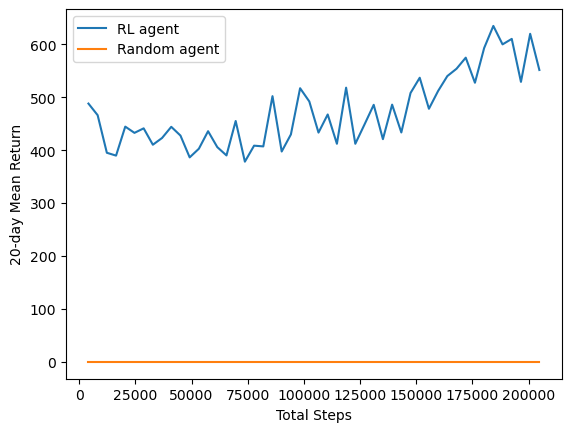

In [722]:
step_logs = agent.buf.eval_step_buf
mean_logs = agent.buf.eval_mean_buf
std_logs = agent.buf.eval_std_buf
plt.plot(step_logs, mean_logs, label='RL agent')

mean_logs_rd = agent.buf.eval_mean_buf_rd
std_logs_rd = agent.buf.eval_std_buf_rd
plt.plot(step_logs, mean_logs_rd, label = 'Random agent')

# plt.axhline(np.mean(pnl_list_eps_one), color='black', linestyle='--', label=f'Baseline: {np.mean(pnl_list_eps_one):.2f}')

plt.xlabel('Total Steps')
plt.ylabel('20-day Mean Return')
plt.legend()
plt.show()


20‑day cumulative PnL:
RL agent:  Mean 424.86. Std 89.22
Persistent agent:  Mean 0.00. Std 0.00
    4096 steps: RL agent avg return:  217.41
20‑day cumulative PnL:
RL agent:  Mean 456.90. Std 53.14
Persistent agent:  Mean 0.00. Std 0.00
    8192 steps: RL agent avg return:  176.47
20‑day cumulative PnL:
RL agent:  Mean 448.73. Std 46.26
Persistent agent:  Mean 0.00. Std 0.00
   12288 steps: RL agent avg return:  322.69
20‑day cumulative PnL:
RL agent:  Mean 436.42. Std 85.23
Persistent agent:  Mean 0.00. Std 0.00
   16384 steps: RL agent avg return:  429.80
20‑day cumulative PnL:
RL agent:  Mean 376.18. Std 73.44
Persistent agent:  Mean 0.00. Std 0.00
   20480 steps: RL agent avg return:  546.23
20‑day cumulative PnL:
RL agent:  Mean 438.45. Std 74.71
Persistent agent:  Mean 0.00. Std 0.00
   24576 steps: RL agent avg return:  625.96
20‑day cumulative PnL:
RL agent:  Mean 467.19. Std 38.14
Persistent agent:  Mean 0.00. Std 0.00
   28672 steps: RL agent avg return:  678.72
20‑day cumula

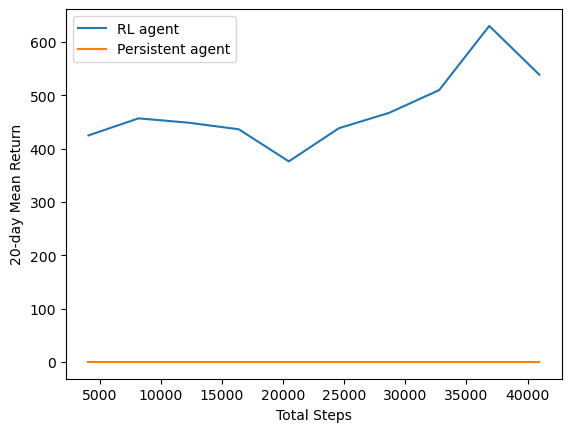

In [688]:
env = DealerMarketEnv2()                  # two-maker env
agent = PPOAgent(env, adapt_hedge=False, eval_days=20, eval_fold=5)
agent.train()


step_logs = agent.buf.eval_step_buf
mean_logs = agent.buf.eval_mean_buf
std_logs = agent.buf.eval_std_buf
plt.plot(step_logs, mean_logs, label='RL agent')

mean_logs_per = agent.buf.eval_mean_buf_rd
std_logs_per = agent.buf.eval_std_buf_rd
plt.plot(step_logs, mean_logs_per, label = 'Persistent agent')

print(len(step_logs))
print(len(mean_logs_per))
# plt.axhline(np.mean(pnl_list_eps_one), color='black', linestyle='--', label=f'Baseline: {np.mean(pnl_list_eps_one):.2f}')

plt.xlabel('Total Steps')
plt.ylabel('20-day Mean Return')
plt.legend()
plt.show()


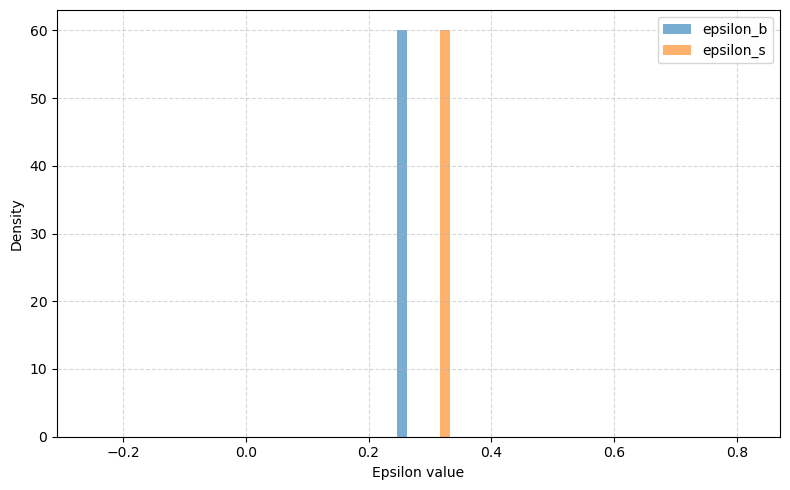

In [734]:
agent.net.eval() 

eps_b_list = []
eps_s_list = []
pnl_list = []
pnl_per_list = []

obs = env.reset()
with torch.no_grad():
    for step in range(3000):
        mu, _ = agent.net.forward(
            torch.as_tensor(obs, dtype=torch.float32, device=CFG.device)
        )
        act = mu.cpu().numpy()           # deterministic (mean) action
        eps_b, eps_s = act[:2]           # first two components
        eps_b_list.append(eps_b)
        eps_s_list.append(eps_s)

        obs, reward, done, info = env.step(act)
        pnl_list.append(reward)
        pnl_per_list.append(info['rnd_pnl'])

epsilons = np.column_stack([eps_b_list, eps_s_list])  # shape (T, 2)

plt.figure(figsize=(8, 5))

plt.hist(eps_b, bins=60, density=True, alpha=0.6, label='epsilon_b')
plt.hist(eps_s, bins=60, density=True, alpha=0.6, label='epsilon_s')

plt.xlabel('Epsilon value')
plt.ylabel('Density')
# plt.title('Empirical density of ε_b and ε_s')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [690]:
print(np.mean(epsilons[:, 0])) #eps_b
print(np.mean(epsilons[:, 1])) #eps_s

0.122744195
0.23451318
